# XGBoost Model

This notebook predicts NSW electricity demand 30 minutes ahead using XGBoost.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load the same dataset used by the baseline and LSTM

In [2]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

DATA_PATH = Path(
    '/content/drive/My Drive/NSW_Electricity_Demand/Data/Processed/Data.parquet'
)
OUTPUT_DIR = Path(
    '/content/drive/My Drive/NSW_Electricity_Demand/Model Outputs/XGBoost'
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(DATA_PATH)
df['DATETIME'] = pd.to_datetime(df['DATETIME'])
df = df.sort_values('DATETIME').reset_index(drop=True)

print('XGBoost version:', xgb.__version__)
print('Rows:', f'{len(df):,}')
print('Period:', df['DATETIME'].min(), 'to', df['DATETIME'].max())

XGBoost version: 3.3.0
Rows: 196,417
Period: 2010-01-03 00:00:00 to 2021-03-18 00:00:00


## 2. Create XGBoost features

All demand and temperature features are based on earlier intervals. Calendar features describe the target timestamp and are known in advance.

In [3]:
# Calendar features
df['XGB_HOUR'] = df['DATETIME'].dt.hour
df['XGB_DAY_OF_WEEK'] = df['DATETIME'].dt.dayofweek
df['XGB_MONTH'] = df['DATETIME'].dt.month
df['XGB_IS_WEEKEND'] = (df['XGB_DAY_OF_WEEK'] >= 5).astype(int)

# Cyclical calendar features
df['XGB_HOUR_SIN'] = np.sin(2 * np.pi * df['XGB_HOUR'] / 24)
df['XGB_HOUR_COS'] = np.cos(2 * np.pi * df['XGB_HOUR'] / 24)
df['XGB_DOW_SIN'] = np.sin(2 * np.pi * df['XGB_DAY_OF_WEEK'] / 7)
df['XGB_DOW_COS'] = np.cos(2 * np.pi * df['XGB_DAY_OF_WEEK'] / 7)
df['XGB_MONTH_SIN'] = np.sin(2 * np.pi * (df['XGB_MONTH'] - 1) / 12)
df['XGB_MONTH_COS'] = np.cos(2 * np.pi * (df['XGB_MONTH'] - 1) / 12)

# Temperature known 30 minutes earlier
df['XGB_TEMP_LAG_1'] = df['TEMPERATURE'].shift(1)
df['XGB_TEMP2'] = df['XGB_TEMP_LAG_1'] ** 2
df['XGB_TEMP3'] = df['XGB_TEMP_LAG_1'] ** 3
df['XGB_TEMP_CHANGE'] = (
    df['TEMPERATURE'].shift(1) - df['TEMPERATURE'].shift(2)
)

# Demand lags: previous half-hours, yesterday and last week
lag_numbers = list(range(1, 49)) + [96, 336]
for lag in lag_numbers:
    df[f'XGB_LAG_{lag}'] = df['TOTALDEMAND'].shift(lag)

# Rolling statistics use only earlier demand
past_demand = df['TOTALDEMAND'].shift(1)
for window in [12, 24, 48, 336]:
    df[f'XGB_ROLL_MEAN_{window}'] = past_demand.rolling(window).mean()
    df[f'XGB_ROLL_STD_{window}'] = past_demand.rolling(window).std()

In [4]:
calendar_features = [
    'XGB_HOUR', 'XGB_DAY_OF_WEEK', 'XGB_MONTH', 'XGB_IS_WEEKEND',
    'XGB_HOUR_SIN', 'XGB_HOUR_COS', 'XGB_DOW_SIN', 'XGB_DOW_COS',
    'XGB_MONTH_SIN', 'XGB_MONTH_COS',
]

temperature_features = [
    'XGB_TEMP_LAG_1', 'XGB_TEMP2', 'XGB_TEMP3', 'XGB_TEMP_CHANGE',
]

lag_features = [f'XGB_LAG_{lag}' for lag in lag_numbers]
rolling_features = [
    f'XGB_ROLL_{stat}_{window}'
    for window in [12, 24, 48, 336]
    for stat in ['MEAN', 'STD']
]

feature_columns = (
    calendar_features + temperature_features + lag_features + rolling_features
)

print('Number of XGBoost features:', len(feature_columns))
print('FORECASTDEMAND used as a feature:', 'FORECASTDEMAND' in feature_columns)

Number of XGBoost features: 72
FORECASTDEMAND used as a feature: False


## 3. Apply the common chronological split

In [5]:
n = len(df)
test_n = int(0.20 * n)
val_n = int(0.10 * n)

train_end = n - val_n - test_n
val_end = n - test_n

df_train = df.iloc[:train_end].copy()
df_val = df.iloc[train_end:val_end].copy()
df_test = df.iloc[val_end:].copy()

print('Training rows:', f'{len(df_train):,}')
print('Validation rows:', f'{len(df_val):,}')
print('Test rows:', f'{len(df_test):,}')

Training rows: 137,493
Validation rows: 19,641
Test rows: 39,283


## 4. Match the LSTM evaluation timestamps

The first 48 validation and test targets are excluded so that XGBoost, the baseline and LSTM are evaluated on the same timestamps.

In [6]:
STEPS = 48

train_aligned = df_train.iloc[STEPS:].copy()
validation_aligned = df_val.iloc[STEPS:].copy()
test_aligned = df_test.iloc[STEPS:].copy()

# The longest lag is unavailable only at the beginning of the training data.
train_aligned = train_aligned.dropna(
    subset=feature_columns + ['TOTALDEMAND']
).copy()
validation_aligned = validation_aligned.dropna(
    subset=feature_columns + ['TOTALDEMAND']
).copy()
test_aligned = test_aligned.dropna(
    subset=feature_columns + ['TOTALDEMAND']
).copy()

print('Training observations:', f'{len(train_aligned):,}')
print('Validation observations:', f'{len(validation_aligned):,}')
print('Test observations:', f'{len(test_aligned):,}')
print('First test prediction:', test_aligned['DATETIME'].iloc[0])

Training observations: 137,157
Validation observations: 19,593
Test observations: 39,235
First test prediction: 2018-12-21 15:00:00


## 5. Train XGBoost

In [7]:
X_train = train_aligned[feature_columns]
y_train = train_aligned['TOTALDEMAND']

X_val = validation_aligned[feature_columns]
y_val = validation_aligned['TOTALDEMAND']

X_test = test_aligned[feature_columns]
y_test = test_aligned['TOTALDEMAND']

model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=1.0,
    early_stopping_rounds=75,
    eval_metric='rmse',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print('Best boosting round:', model.best_iteration)
print('Best validation RMSE:', model.best_score)

Best boosting round: 1999
Best validation RMSE: 65.02462407803901


## 6. Evaluate the test predictions

In [8]:
y_pred = model.predict(X_test)

errors = y_pred - y_test.to_numpy()
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = (np.abs(errors) / y_test.to_numpy()).mean() * 100
r2 = r2_score(y_test, y_pred)
bias = errors.mean()

xgboost_metrics = pd.DataFrame([{
    'Model': 'XGBoost',
    'Observations': len(y_test),
    'MAE': mae,
    'RMSE': rmse,
    'MAPE': mape,
    'R2': r2,
    'Bias': bias,
}])

display(xgboost_metrics.round({
    'MAE': 2, 'RMSE': 2, 'MAPE': 2, 'R2': 4, 'Bias': 2
}))

,Model,Observations,MAE,RMSE,MAPE,R2,Bias
0,XGBoost,39235,61.14,83.63,0.79,0.9955,8.11


## 7. Save predictions and the trained model

In [9]:
xgboost_predictions = pd.DataFrame({
    'DATETIME': test_aligned['DATETIME'].to_numpy(),
    'TOTALDEMAND': y_test.to_numpy(),
    'XGBoost_Prediction': y_pred,
})

xgboost_metrics.to_csv(
    OUTPUT_DIR / 'xgboost_test_metrics.csv', index=False
)
xgboost_predictions.to_parquet(
    OUTPUT_DIR / 'xgboost_predictions.parquet', index=False
)
model.save_model(OUTPUT_DIR / 'xgboost_model.json')
joblib.dump(feature_columns, OUTPUT_DIR / 'xgboost_feature_names.joblib')

print('Saved outputs to:', OUTPUT_DIR)
print('Saved prediction rows:', f'{len(xgboost_predictions):,}')

Saved outputs to: /content/drive/My Drive/NSW_Electricity_Demand/Model Outputs/XGBoost
Saved prediction rows: 39,235


## 8. Feature importance

,Feature,Importance
0,XGB_LAG_1,0.680451
1,XGB_LAG_2,0.198949
2,XGB_HOUR_COS,0.025652
3,XGB_LAG_336,0.023868
4,XGB_HOUR,0.007519
5,XGB_LAG_3,0.006810
6,XGB_HOUR_SIN,0.005963
7,XGB_LAG_46,0.005440
8,XGB_LAG_48,0.004293
9,XGB_LAG_4,0.003563


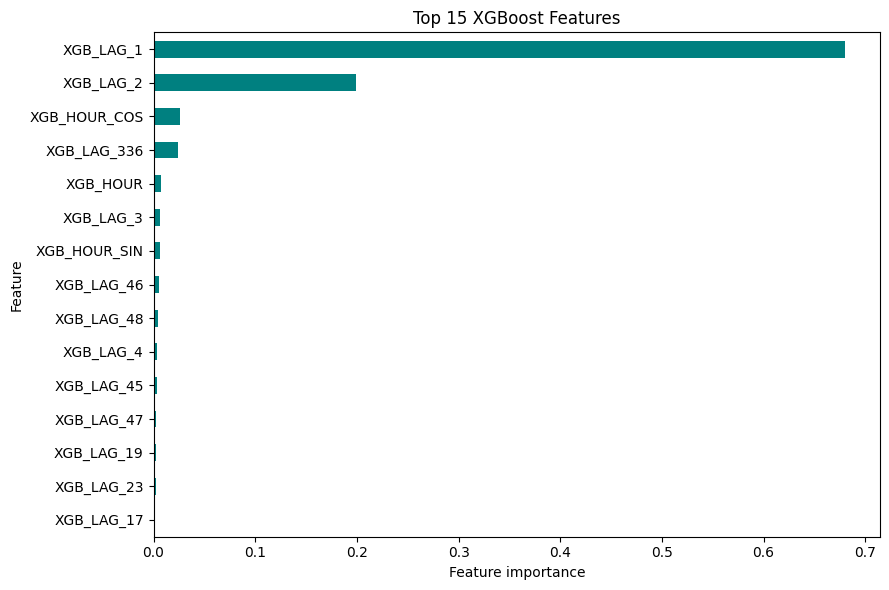

In [10]:
feature_importance = (
    pd.DataFrame({
        'Feature': feature_columns,
        'Importance': model.feature_importances_,
    })
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

feature_importance.to_csv(
    OUTPUT_DIR / 'xgboost_feature_importance.csv', index=False
)
display(feature_importance.head(15))

plot_importance = feature_importance.head(15).sort_values('Importance')
plot_importance.plot(
    kind='barh', x='Feature', y='Importance',
    figsize=(9, 6), legend=False, color='teal'
)
plt.title('Top 15 XGBoost Features')
plt.xlabel('Feature importance')
plt.tight_layout()
plt.show()

## 9. Actual versus predicted demand

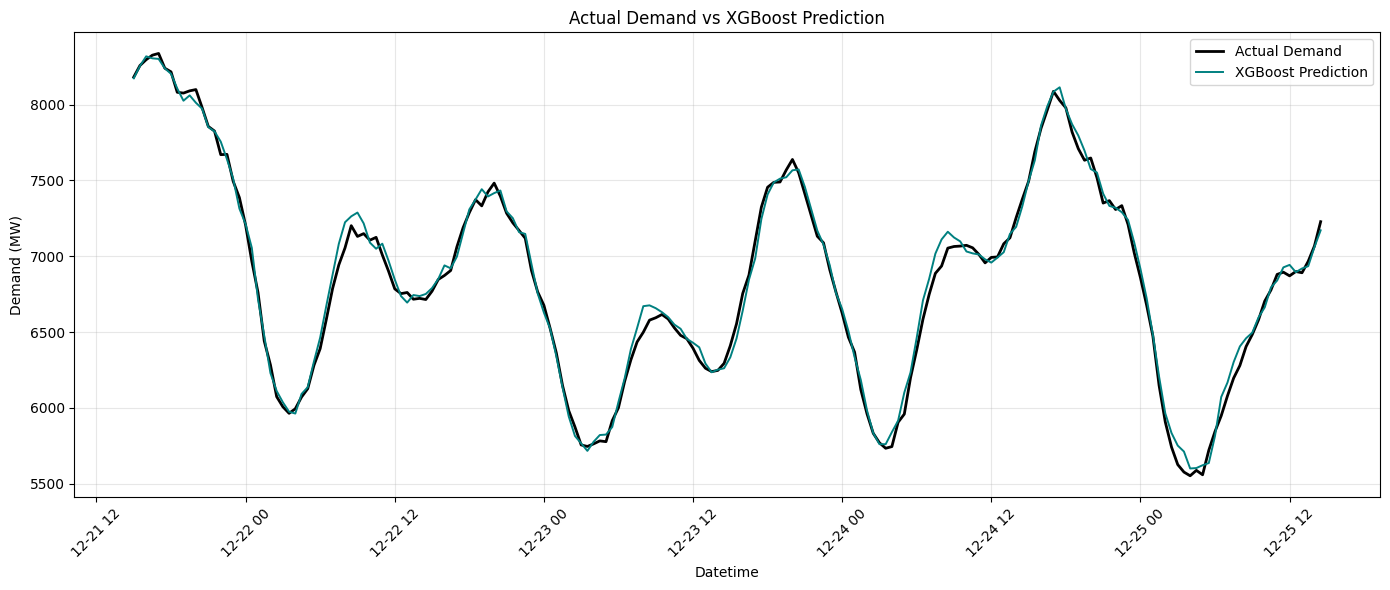

In [12]:
plot_data = xgboost_predictions.iloc[:48 * 4]

plt.figure(figsize=(14, 6))
plt.plot(
    plot_data['DATETIME'], plot_data['TOTALDEMAND'],
    label='Actual Demand', color='black', linewidth=2
)
plt.plot(
    plot_data['DATETIME'], plot_data['XGBoost_Prediction'],
    label='XGBoost Prediction', color='teal', linewidth=1.4
)
plt.title('Actual Demand vs XGBoost Prediction')
plt.xlabel('Datetime')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

These test metrics are a check for the XGBoost notebook. The final comparison notebook will merge the saved predictions by `DATETIME` and recalculate every model's metrics on the common timestamps.